In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pickle

# Plotting params

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # Times for publication
    "font.size": 11,                    # Base font size
    "axes.labelsize": 11,              # Axis label font size
    "axes.labelweight": "bold",         # Bold axis labels
    "font.weight": "bold",          # Bold font for all text
    "axes.titlesize": 11,              # Axis title (not fig title)
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,              # Legend font size

    "figure.dpi": 300,                 # Display resolution
    "savefig.dpi": 300,                # Save resolution
    "figure.figsize": (6.5,4),     # For 0.5\textwidth plot
    # "figure.constrained_layout.use": True,  # Better spacing than tight_layout

    "axes.linewidth": 0.8,             # Thin but clear axes lines
    "lines.linewidth": 1.2,
    "lines.markersize": 5,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "xtick.direction": "in",
    "ytick.direction": "in", 
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "legend.frameon": False,
    "legend.handlelength": 1.0,        # Slightly longer legend lines
    "legend.handletextpad": 0.5,

    "pdf.fonttype": 42,                # Embed editable fonts in PDF
    "ps.fonttype": 42
})

folder_name = 'PLOTS_IGT'

save_fig = True
alpha = 1

# PD and Normal CONDITION

In [3]:
# Reading PD pickle file
# read pickle file
with open(r'DATA/igt_normal_simulation.pkl', 'rb') as f:
    normal_results_IGT = pickle.load(f)

with open(r'DATA/igt_pd_simulation.pkl', 'rb') as f:
    pd_results_IGT = pickle.load(f)

# Extracting PD results
IGT_simulated_pd = pd_results_IGT['IGT_sim']
IGT_std_simulated_pd = pd_results_IGT['IGT_sim_std']
n_sim_pd = pd_results_IGT['n_sim'] 

IGT_experimental_pd = pd_results_IGT['IGT_exp']
IGT_std_experimental_pd = pd_results_IGT['IGT_exp_std']
n_expt_pd = pd_results_IGT['n_expt']

# Extracting normal results
IGT_simulated_normal = normal_results_IGT['IGT_sim']
IGT_std_simulated_normal = normal_results_IGT['IGT_sim_std']
n_sim_normal = normal_results_IGT['n_sim']

IGT_experimental_normal = normal_results_IGT['IGT_exp']
IGT_std_experimental_normal = normal_results_IGT['IGT_exp_std']
n_expt_normal = normal_results_IGT['n_expt']
BINS = np.arange(5)+ 1


In [4]:
normal_results_IGT['statistical test']

,Index,Exp Mean,Sim Mean,t-stat,p-value,Significant,Conclusion
0,1,-1.83,0.20,-1.581,0.1254,False,Not statistically different
1,2,1.50,1.92,-0.270,0.7892,False,Not statistically different
2,3,2.60,2.28,0.222,0.8263,False,Not statistically different
3,4,4.59,3.92,0.570,0.5733,False,Not statistically different
4,5,3.90,3.80,0.080,0.9372,False,Not statistically different


# DBS CONDITION COMPARISON

In [5]:
# Read the data from the pickle file
with open("DATA/igt_5th_bin_scores_PD.pkl", "rb") as f:
    data_loaded_PD = pickle.load(f)

with open("DATA/igt_5th_bin_scores_DBS_open_loop_low_amp.pkl", "rb") as f:
    data_loaded_DBS_open_loop_lowamp = pickle.load(f)

with open("Data/igt_5th_bin_scores_DBS_open_loop_high_amp.pkl", "rb") as f:
    data_loaded_DBS_open_loop_highamp = pickle.load(f)

with open("Data/igt_5th_bin_scores_DBS_closed_loop.pkl", "rb") as f:
    data_loaded_DBS_close_loop = pickle.load(f)


with open("DATA/igt_5th_bin_scores_std_DBS.pkl", "rb") as f:
    data_loaded_std_DBS = pickle.load(f)

In [6]:
# Extract data from the loaded pickle files
del_lim_values_PD = data_loaded_PD["del_lim"]
igt_scores_PD = data_loaded_PD["igt_scores"]
igt_errors_PD = data_loaded_PD["igt_errors"]

del_lim_values_DBS_std = data_loaded_std_DBS["del_lim"]
igt_scores_DBS_std = data_loaded_std_DBS["igt_scores"]
igt_errors_DBS_std = data_loaded_std_DBS["igt_errors"]

del_lim_values_DBS_open_low = data_loaded_DBS_open_loop_lowamp["del_lim"]
igt_scores_DBS_open_low = data_loaded_DBS_open_loop_lowamp["igt_scores"]
igt_errors_DBS_open_low = data_loaded_DBS_open_loop_lowamp["igt_errors"]

del_lim_values_DBS_open_high = data_loaded_DBS_open_loop_highamp["del_lim"]
igt_scores_DBS_open_high = data_loaded_DBS_open_loop_highamp["igt_scores"]
igt_errors_DBS_open_high = data_loaded_DBS_open_loop_highamp["igt_errors"]/2

del_lim_values_DBS_closed = data_loaded_DBS_close_loop["del_lim"]
igt_scores_DBS_closed = data_loaded_DBS_close_loop["igt_scores"]
igt_errors_DBS_closed = data_loaded_DBS_close_loop["igt_errors"]/2

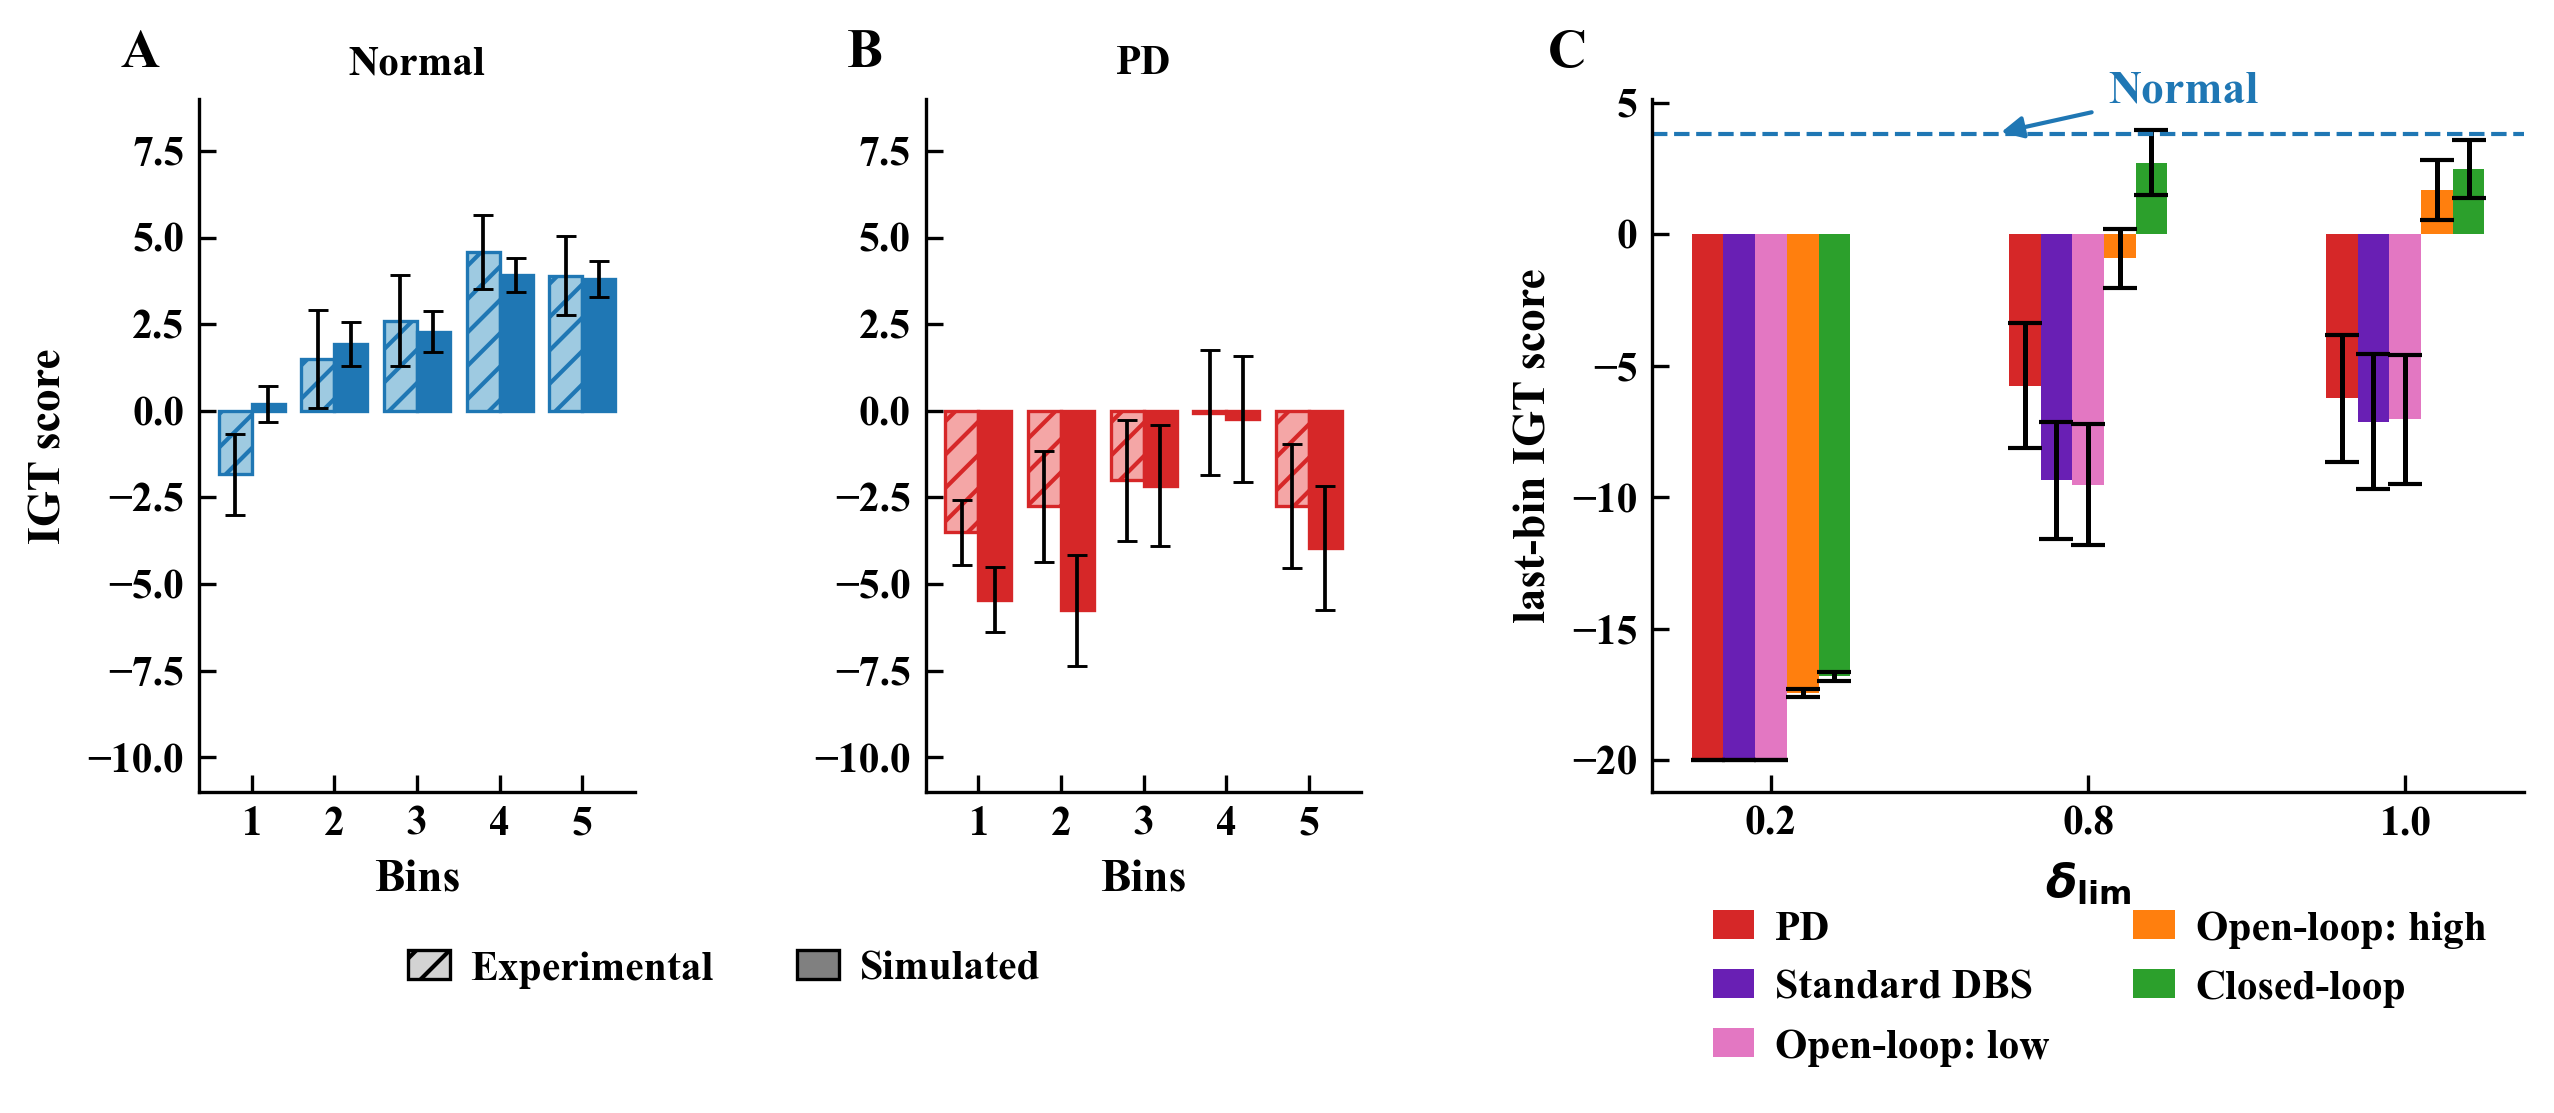

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

fig = plt.figure(
    figsize=(10, 3),
    dpi=300,
    constrained_layout=False
)

gs = gridspec.GridSpec(
    1,
    3,
    width_ratios=[0.5, 0.5, 1]
)

# ============================================================
# Colors and style
# ============================================================
normal_sim_color = 'tab:blue'
normal_expt_color = '#9ecae1'   # lighter blue

pd_sim_color = 'tab:red'
pd_expt_color = '#f4a6a6'       # lighter red

error_color = 'black'
bar_width = 0.4

# ============================================================
# Subplot 1: Normal
# ============================================================
ax1 = fig.add_subplot(gs[0])

ax1.bar(
    BINS,
    IGT_experimental_normal,
    width=bar_width,
    color=normal_expt_color,
    edgecolor=normal_sim_color,
    linewidth=0.8,
    hatch='///',
    label='Experimental'
)

ax1.bar(
    BINS + bar_width,
    IGT_simulated_normal,
    width=bar_width,
    color=normal_sim_color,
    edgecolor=normal_sim_color,
    linewidth=0.8,
    alpha=alpha,
    label='Simulated'
)

ax1.errorbar(
    BINS,
    IGT_experimental_normal,
    yerr=IGT_std_experimental_normal / np.sqrt(n_expt_normal),
    fmt='none',
    ecolor=error_color,
    elinewidth=0.9,
    capsize=2.5,
    capthick=0.7
)

ax1.errorbar(
    BINS + bar_width,
    IGT_simulated_normal,
    yerr=IGT_std_simulated_normal / np.sqrt(n_sim_normal),
    fmt='none',
    ecolor=error_color,
    elinewidth=0.9,
    capsize=2.5,
    capthick=0.7
)

ax1.set_ylim(-11, 9)
ax1.set_xlabel('Bins')
ax1.set_ylabel('IGT score')
ax1.set_xticks(BINS + bar_width / 2)
ax1.set_xticklabels([str(b) for b in BINS])
ax1.set_title('Normal', fontsize=10, weight='bold')

# ============================================================
# Subplot 2: PD
# ============================================================
ax2 = fig.add_subplot(gs[1])

ax2.bar(
    BINS,
    IGT_experimental_pd,
    width=bar_width,
    color=pd_expt_color,
    edgecolor=pd_sim_color,
    linewidth=0.8,
    hatch='///',
    label='Experimental'
)

ax2.bar(
    BINS + bar_width,
    IGT_simulated_pd,
    width=bar_width,
    color=pd_sim_color,
    edgecolor=pd_sim_color,
    linewidth=0.8,
    alpha=alpha,
    label='Simulated'
)

ax2.errorbar(
    BINS,
    IGT_experimental_pd,
    yerr=IGT_std_experimental_pd / np.sqrt(n_expt_pd),
    fmt='none',
    ecolor=error_color,
    elinewidth=0.9,
    capsize=2.5,
    capthick=0.7
)

ax2.errorbar(
    BINS + bar_width,
    IGT_simulated_pd,
    yerr=IGT_std_simulated_pd / np.sqrt(n_sim_pd),
    fmt='none',
    ecolor=error_color,
    elinewidth=0.9,
    capsize=2.5,
    capthick=0.7
)

ax2.set_ylim(-11, 9)
ax2.set_xlabel('Bins')
ax2.set_xticks(BINS + bar_width / 2)
ax2.set_xticklabels([str(b) for b in BINS])
ax2.set_title('PD', fontsize=10, weight='bold')

# ============================================================
# Shared legend for experimental vs simulated
# ============================================================
comparison_handles = [
    Patch(
        facecolor='lightgray',
        edgecolor='black',
        hatch='///',
        linewidth=0.8,
        label='Experimental'
    ),
    Patch(
        facecolor='gray',
        edgecolor='black',
        linewidth=0.8,
        label='Simulated'
    )
]

fig.legend(
    handles=comparison_handles,
    loc='lower center',
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.30, -0.150),
)



# ============================================================
# Subplot 3: DBS comparison
# ============================================================
ax3 = fig.add_subplot(gs[2])

bar_width = 0.1
x_values = np.arange(len(del_lim_values_PD))

ax3.bar(
    x_values - bar_width * 2,
    igt_scores_PD,
    width=bar_width,
    label='PD',
    alpha=alpha,
    color='tab:red',
    yerr=igt_errors_PD,
    capsize=4
)

ax3.bar(
    x_values - bar_width,
    igt_scores_DBS_std,
    width=bar_width,
    label='Standard DBS',
    alpha=alpha,
    color='#691fb4',
    yerr=igt_errors_DBS_std,
    capsize=4
)

ax3.bar(
    x_values,
    igt_scores_DBS_open_low,
    width=bar_width,
    label='Open-loop: low',
    alpha=alpha,
    color='#e377c2',
    yerr=igt_errors_DBS_open_low,
    capsize=4
)

ax3.bar(
    x_values + bar_width,
    igt_scores_DBS_open_high,
    width=bar_width,
    label='Open-loop: high',
    alpha=alpha,
    color='#ff7f0e',
    yerr=igt_errors_DBS_open_high,
    capsize=4
)

ax3.bar(
    x_values + bar_width * 2,
    igt_scores_DBS_closed,
    width=bar_width,
    label='Closed-loop',
    alpha=alpha,
    color='#2ca02c',
    yerr=igt_errors_DBS_closed,
    capsize=4
)

# Normal-condition reference line
ax3.axhline(
    y=IGT_simulated_normal[-1],
    color='tab:blue',
    linestyle='--',
    linewidth=1.0
)

ax3.annotate(
    'Normal',
    xy=(0.7, IGT_simulated_normal[-1]),
    xytext=(1.3, 5),
    arrowprops=dict(
        arrowstyle='-|>',
        lw=1.0,
        color='tab:blue'
    ),
    fontsize=11,
    color='tab:blue',
    ha='center'
)

ax3.set_xlabel(r'$\delta_{\mathrm{lim}}$')
ax3.set_ylabel('last-bin IGT score')

ax3.set_xticks(x_values)
ax3.set_xticklabels(
    [f'{v:.1f}' for v in del_lim_values_PD],
    rotation=0
)

ax3.legend(
    loc='lower right',
    frameon=False,
    bbox_to_anchor=(1.0, -0.45),
    ncol=2
)

# ============================================================
# Layout and saving
# ============================================================
fig.subplots_adjust(wspace=0.5)

ax1.text(
    -0.18, 1.1, 'A',
    transform=ax1.transAxes,
    fontsize=13,
    fontweight='bold',
    va='top'
)

ax2.text(
    -0.18, 1.1, 'B',
    transform=ax2.transAxes,
    fontsize=13,
    fontweight='bold',
    va='top'
)

ax3.text(
    -0.12, 1.1, 'C',
    transform=ax3.transAxes,
    fontsize=13,
    fontweight='bold',
    va='top'
)

if save_fig:
    plt.savefig(
        f'{folder_name}/IGT_all.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/IGT_all.svg',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/IGT_all.eps',
        dpi=300,
        bbox_inches='tight'
    )
    plt.savefig(
        f'{folder_name}/IGT_all.pdf',
        dpi=300,
        bbox_inches='tight'
    )


plt.show()

In [8]:
print(f'last bin IGT under Normal: {IGT_simulated_normal[-1]}')
print(f'last bin IGT under Normal: {igt_scores_PD[-1]}')
print(f'last bin IGT under Closed loop DBS (del lim = 1.0): {igt_scores_DBS_closed[-1]}')
print(f'last bin IGT under Open loop high (del lim = 1.0): {igt_scores_DBS_open_high[-1]}')
print(f'last bin IGT under Open loop low (del lim = 1.0): {igt_scores_DBS_open_low[-1]}')
print(f'last bin IGT under std DBS (del lim = 1.0): {igt_scores_DBS_std[-1]}')

last bin IGT under Normal: 3.799999952316284
last bin IGT under Normal: -6.239999771118164
last bin IGT under Closed loop DBS (del lim = 1.0): 2.4800000190734863
last bin IGT under Open loop high (del lim = 1.0): 1.6799999475479126
last bin IGT under Open loop low (del lim = 1.0): -7.039999961853027
last bin IGT under std DBS (del lim = 1.0): -7.119999885559082


In [9]:
# Compute and print RMSE (no functions)\n
sim_normal = np.asarray(IGT_simulated_normal, dtype=float)
exp_normal = np.asarray(IGT_experimental_normal, dtype=float)
rmse_normal = np.sqrt(np.mean((sim_normal - exp_normal) ** 2))
per_bin_normal = np.sqrt((sim_normal - exp_normal) ** 2)
print('RMSE (Normal):', rmse_normal)
print('Per-bin RMSE (Normal):', per_bin_normal.tolist())

sim_pd = np.asarray(IGT_simulated_pd, dtype=float)
exp_pd = np.asarray(IGT_experimental_pd, dtype=float)
rmse_pd = np.sqrt(np.mean((sim_pd - exp_pd) ** 2))
per_bin_pd = np.sqrt((sim_pd - exp_pd) ** 2)
print('RMSE (PD):', rmse_pd)
print('Per-bin RMSE (PD):', per_bin_pd.tolist())

RMSE (Normal): 0.9857585811611551
Per-bin RMSE (Normal): [2.0300000029802323, 0.41999995708465576, 0.3200000286102296, 0.6699999237060545, 0.10000004768371573]
RMSE (PD): 1.6963726448953247
Per-bin RMSE (PD): [1.9499998092651367, 3.010000228881836, 0.16000008583068848, 0.18999999463558198, 1.2100000381469727]
